# Waterbirds — Spurious Correlation 완화 실험

**과제 목표.** 이미지 분류기가 대상(새) 자체가 아니라 **배경**을 보고 판단하는 문제(spurious correlation)를
얼마나 줄일 수 있는지 비교한다.

**데이터.** WILDS의 Waterbirds. 학습 데이터에서 물새는 대부분 물 배경, 육지새는 대부분 땅 배경에 등장한다.
그래서 모델이 "배경이 물이면 물새"라는 지름길(shortcut)을 학습하기 쉽다.
평가는 아래 네 그룹으로 나눠서 하고, **worst-group 정확도**(가장 낮은 그룹의 정확도)를 주 지표로 쓴다.

| 그룹 | 구성 | 비고 |
|---|---|---|
| G0 | 육지새 + 땅 | 다수 |
| G1 | 육지새 + 물 | 소수 |
| G2 | 물새 + 땅 | **소수, 최소 — worst** |
| G3 | 물새 + 물 | 다수 |

**비교한 접근 두 가지.**

1. **알고리즘을 고치기** — GroupDRO. 손실이 큰 그룹에 가중치를 몰아주어 최악 그룹을 직접 최적화한다.
2. **데이터를 고치기** — 배경 랜덤화. DeepLabV3로 새를 분리한 뒤 배경을 무작위로 갈아끼워,
   학습 데이터 안의 새-배경 상관 자체를 끊는다.

**실행 환경.** Google Colab (GPU), 체크포인트와 결과는 Google Drive에 저장.
전체 재현은 `런타임 → 런타임 다시 시작 및 모두 실행`. 이미 끝난 실험은 `result.json`이 있으면 건너뛴다.


## 0. 환경 설정

In [2]:
!pip install wilds -q

import os, random, time, json, gc
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from tqdm.auto import tqdm

def set_seed(seed=0):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 9.0 MB/s eta 0:00:00
device: cuda
GPU: Tesla T4


In [3]:
# 한글 폰트 설치 및 등록
!apt-get install -qq -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("한글 폰트 적용 완료")

한글 폰트 적용 완료


In [4]:
from google.colab import drive
drive.mount('/content/drive')

ROOT = "/content/drive/MyDrive/gihaksim"
CKPT_DIR = os.path.join(ROOT, "ckpt")
os.makedirs(CKPT_DIR, exist_ok=True)
print("ckpt 저장 위치:", CKPT_DIR)

Mounted at /content/drive
ckpt 저장 위치: /content/drive/MyDrive/gihaksim/ckpt


In [5]:
import os

WB_DIR = "/content/wb_data/waterbirds_v1.0"

if not os.path.exists(os.path.join(WB_DIR, "metadata.csv")):
    !wget --show-progress -O /content/wb.tar.gz \
        https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz
    !mkdir -p /content/wb_data
    !tar -xzf /content/wb.tar.gz -C /content/wb_data
    !mv /content/wb_data/waterbird_complete95_forest2water2 {WB_DIR}
    # WILDS가 버전 확인용으로 찾는 파일
    !touch {WB_DIR}/RELEASE_v1.0.txt

print(os.listdir(WB_DIR)[:5])

--2026-09-27 09:13:27--  https://nlp.stanford.edu/data/dro/waterbird_complete95_forest2water2.tar.gz
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/dro/waterbird_complete95_forest2water2.tar.gz [following]
--2026-09-27 09:13:28--  https://downloads.cs.stanford.edu/nlp/data/dro/waterbird_complete95_forest2water2.tar.gz
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 489698023 (467M) [application/octet-stream]
Saving to: ‘/content/wb.tar.gz’

/content/wb.tar.gz  100%[===================>] 467.01M  5.02MB/s    in 89s     

2026-09-27 09:14:58 (5.23 MB/s) - ‘/content/wb.tar.gz’ saved [489698023/4

In [6]:
import os

print("=== 1. tar.gz ===")
p = "/content/wb.tar.gz"
if os.path.exists(p):
    print(f"  있음, {os.path.getsize(p)/1e6:.1f} MB")
    with open(p, "rb") as f:
        head = f.read(4)
    print("  gzip 맞음" if head[:2] == b"\x1f\x8b" else f"  gzip 아님! 앞부분={head}")
else:
    print("  없음 ← 다운로드 자체가 안 됨")

print("\n=== 2. /content/wb_data ===")
d = "/content/wb_data"
print("  존재:", os.path.exists(d))
if os.path.exists(d):
    print("  내용:", os.listdir(d))

print("\n=== 3. waterbirds_v1.0 ===")
w = "/content/wb_data/waterbirds_v1.0"
print("  존재:", os.path.exists(w))
if os.path.exists(w):
    items = sorted(os.listdir(w))
    print(f"  항목 {len(items)}개:", items[:8])
    print("  metadata.csv:", os.path.exists(os.path.join(w, "metadata.csv")))

print("\n=== 4. 디스크 여유 ===")
!df -h /content | tail -1

=== 1. tar.gz ===
  있음, 489.7 MB
  gzip 맞음

=== 2. /content/wb_data ===
  존재: True
  내용: ['waterbirds_v1.0']

=== 3. waterbirds_v1.0 ===
  존재: True
  항목 202개: ['001.Black_footed_Albatross', '002.Laysan_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet']
  metadata.csv: True

=== 4. 디스크 여유 ===
overlay         236G   49G  188G  21% /


## 1. 데이터와 그룹 정의

`make_group(y, place) = y*2 + place` 로 (새 종류 × 배경) 4개 그룹을 만든다.
전처리는 ImageNet 사전학습 ResNet-50에 맞춰 Resize(256) → CenterCrop(224) → 정규화.

In [7]:
from wilds import get_dataset
from torchvision import transforms
from torch.utils.data import DataLoader

GROUP_NAMES = {
    0: "G0: 육지새 + 땅 (다수)",
    1: "G1: 육지새 + 물 (소수)",
    2: "G2: 물새 + 땅 (소수, 최소) ★ worst",
    3: "G3: 물새 + 물 (다수)",
}
N_GROUPS = 4

def make_group(y, md_meta):
    return (y * 2 + md_meta[:, 0]).long()

def get_transform():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

LOCAL_DATA = "/content/wb_data"
full = get_dataset(dataset="waterbirds", download=False, root_dir=LOCAL_DATA)
tform = get_transform()

train_set = full.get_subset("train", transform=tform)
val_set   = full.get_subset("val",   transform=tform)
test_set  = full.get_subset("test",  transform=tform)

BATCH = 128
def loader(ds, shuffle):
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader = loader(train_set, True)
val_loader   = loader(val_set,   False)
test_loader  = loader(test_set,  False)
print("로더 준비 완료")

/usr/local/lib/python3.13/dist-packages/outdated/__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


로더 준비 완료


In [8]:
from torchvision import models

def get_resnet50(num_classes=2):
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    model = models.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## 2. 손실 함수 — ERM vs GroupDRO

**ERM**은 전체 평균 손실을 줄인다. 다수 그룹이 데이터의 대부분이므로 소수 그룹은 사실상 무시된다.

**GroupDRO**는 그룹별 손실 `L_g`를 따로 구한 뒤, 그룹 가중치 `q`를
`q_g ← q_g · exp(η·L_g)` 로 갱신하고 정규화한다. 손실이 큰 그룹일수록 가중치가 커지므로
최종 목적함수 `Σ q_g·L_g` 는 최악 그룹 쪽으로 끌려간다. `η`(eta)는 그 반응 속도다.

In [9]:
class GroupDROLoss:
    def __init__(self, n_groups, eta=0.01, device="cuda"):
        self.n_groups = n_groups
        self.eta = eta
        self.device = device
        self.q = torch.ones(n_groups, device=device) / n_groups
        self.ce = nn.CrossEntropyLoss(reduction="none")
    def compute(self, logits, y, groups):
        per_sample = self.ce(logits, y)
        group_loss = torch.zeros(self.n_groups, device=self.device)
        for g in range(self.n_groups):
            m = (groups == g)
            if m.sum() > 0:
                group_loss[g] = per_sample[m].mean()
        self.q = self.q * torch.exp(self.eta * group_loss.detach())
        self.q = self.q / self.q.sum()
        return (self.q * group_loss).sum()

class ERMLoss:
    def __init__(self):
        self.ce = nn.CrossEntropyLoss()
    def compute(self, logits, y, groups):
        return self.ce(logits, y)

## 3. 평가와 학습 루프

평가는 그룹별 정확도를 모두 내고 그중 최솟값을 worst로 잡는다.
모델 선택 기준은 **validation worst-group 정확도**이며, 그 시점의 가중치를 저장해 test에 쓴다.
(평균 정확도로 고르면 소수 그룹을 버린 모델이 뽑히기 때문이다.)

In [10]:
@torch.no_grad()
def evaluate(model, data_loader, device):
    model.eval()
    correct = torch.zeros(N_GROUPS); total = torch.zeros(N_GROUPS)
    for x, y, mdm in data_loader:
        x, y = x.to(device), y.to(device)
        g = make_group(y.cpu(), mdm)
        pred = model(x).argmax(1).cpu()
        ok = (pred == y.cpu())
        for gi in range(N_GROUPS):
            m = (g == gi)
            correct[gi] += ok[m].sum(); total[gi] += m.sum()
    group_acc = (correct / total.clamp(min=1)).tolist()
    avg_acc = (correct.sum() / total.sum()).item()
    worst = min(a for a, t in zip(group_acc, total.tolist()) if t > 0)
    return {"avg": avg_acc, "worst": worst, "per_group": group_acc}

In [11]:
def train_experiment(name, method, weight_decay, lr, epochs=100, eta=0.01, seed=0):
    set_seed(seed)
    model = get_resnet50().to(DEVICE)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    crit = GroupDROLoss(N_GROUPS, eta=eta, device=DEVICE) if method == "dro" else ERMLoss()

    best_worst = -1.0
    best_path = os.path.join(CKPT_DIR, f"{name}_best.pt")
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        pbar = tqdm(train_loader, desc=f"{name} ep{epoch}/{epochs}", leave=False)
        for x, y, mdm in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)
            g = make_group(y.cpu(), mdm).to(DEVICE)
            optimizer.zero_grad()
            loss = crit.compute(model(x), y, g)
            loss.backward(); optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.3f}")

        val = evaluate(model, val_loader, DEVICE)
        history.append({"epoch": epoch, "avg": val["avg"], "worst": val["worst"]})
        if val["worst"] > best_worst:
            best_worst = val["worst"]
            torch.save(model.state_dict(), best_path)
        print(f"[{name}] ep{epoch:3d} val_avg={val['avg']:.3f} val_worst={val['worst']:.3f} (best={best_worst:.3f})")

    model.load_state_dict(torch.load(best_path))
    test = evaluate(model, test_loader, DEVICE)
    print(f"[{name}] === TEST: avg={test['avg']:.3f} worst={test['worst']:.3f} ===")
    json.dump({"name": name, "test": test, "best_val_worst": best_worst, "history": history},
              open(os.path.join(CKPT_DIR, f"{name}_result.json"), "w"),
              ensure_ascii=False, indent=2)
    return {"name": name, "test": test, "history": history}

## 4. 실험 설계 (E1~E4)

정규화 강도와 손실 함수를 교차한 2×2 설계다.
GroupDRO는 강한 L2 정규화와 함께 써야 효과가 난다고 알려져 있어, 그 조건을 분리해 확인하는 것이 목적이다.

| | ERM | GroupDRO |
|---|---|---|
| **약한 L2** (wd=1e-4, lr=1e-3) | E1 | E2 |
| **강한 L2** (wd=1.0, lr=1e-5) | E4 | E3 |

아래 학습 로그는 세션이 중간에 끊긴 기록의 일부(E1의 32에폭까지)이며,
완료된 네 실험의 최종 수치는 Drive의 `{실험명}_result.json`에 저장되어 있고 다음 셀 표에 정리된다.


In [12]:
EPOCHS = 100

# 2x2 설계: (ERM vs GroupDRO) x (약한 L2 vs 강한 L2)
EXPERIMENTS = {
    "E1_ERM_weak":   dict(method="erm", weight_decay=1e-4, lr=1e-3),
    "E2_DRO_weak":   dict(method="dro", weight_decay=1e-4, lr=1e-3, eta=0.01),
    "E3_DRO_strong": dict(method="dro", weight_decay=1.0,  lr=1e-5, eta=0.01),
    "E4_ERM_strong": dict(method="erm", weight_decay=1.0,  lr=1e-5),
}


In [13]:
results = {}
for name, cfg in EXPERIMENTS.items():
    rpath = os.path.join(CKPT_DIR, f"{name}_result.json")
    if os.path.exists(rpath):
        print(f"[{name}] 이미 완료 — 건너뜀")
        results[name] = json.load(open(rpath))
        continue
    print(f"\n========== {name} ==========")
    results[name] = train_experiment(name, epochs=EPOCHS, **cfg)
    gc.collect(); torch.cuda.empty_cache()

[E1_ERM_weak] 이미 완료 — 건너뜀
[E2_DRO_weak] 이미 완료 — 건너뜀
[E3_DRO_strong] 이미 완료 — 건너뜀
[E4_ERM_strong] 이미 완료 — 건너뜀


In [14]:
import os, json

ALL = ["E1_ERM_weak", "E2_DRO_weak", "E3_DRO_strong", "E4_ERM_strong"]

print(f"{'실험':<18}{'avg':>8}{'worst':>8}")
print("-" * 36)
loaded = {}
for name in ALL:
    p = os.path.join(CKPT_DIR, f"{name}_result.json")
    if os.path.exists(p):
        t = json.load(open(p))["test"]
        loaded[name] = t
        print(f"{name:<18}{t['avg']:>8.3f}{t['worst']:>8.3f}")
    else:
        print(f"{name:<18}{'(아직 없음)':>16}")

# 논문 Table 1 형태로 정리
print("\n=== Waterbirds worst-group (논문 Table 1 재현) ===")
print(f"{'':<12}{'ERM':>8}{'DRO':>8}")
if "E1_ERM_weak" in loaded and "E2_DRO_weak" in loaded:
    print(f"{'약한 L2':<12}{loaded['E1_ERM_weak']['worst']:>8.3f}{loaded['E2_DRO_weak']['worst']:>8.3f}")
if "E4_ERM_strong" in loaded and "E3_DRO_strong" in loaded:
    print(f"{'강한 L2':<12}{loaded['E4_ERM_strong']['worst']:>8.3f}{loaded['E3_DRO_strong']['worst']:>8.3f}")

실험                     avg   worst
------------------------------------
E1_ERM_weak          0.857   0.678
E2_DRO_weak          0.923   0.854
E3_DRO_strong        0.906   0.862
E4_ERM_strong        0.765   0.184

=== Waterbirds worst-group (논문 Table 1 재현) ===
                 ERM     DRO
약한 L2          0.678   0.854
강한 L2          0.184   0.862


### 1차 결과 해석

- **E1 (ERM, 약한 L2) worst 0.678** — 평균은 0.857로 멀쩡해 보이지만 최악 그룹에서 크게 떨어진다.
  평균 정확도만 보면 이 문제가 보이지 않는다는 점이 핵심이다.
- **E4 (ERM, 강한 L2) worst 0.184** — 강한 정규화를 걸어도 ERM이면 오히려 최악 그룹이 무너진다.
  정규화 자체가 해법이 아니라는 반례다.
- **E2·E3 (GroupDRO) worst 0.854 / 0.862** — 그룹 라벨을 쓰는 것만으로 최악 그룹이 크게 개선된다.
  강한 L2와 함께 쓴 E3가 조금 더 높다.


## 5. 배경 랜덤화 — 데이터 쪽에서 상관을 끊기

GroupDRO는 학습 중에 그룹 라벨이 필요하다. 여기서는 **데이터 자체를 고치는** 다른 접근을 시도한다.

1. DeepLabV3(ResNet-101, Pascal VOC 사전학습)로 각 이미지에서 새 영역 마스크를 뽑는다.
2. 새를 지운 나머지를 배경 풀에 모은다(땅/물 각각).
3. 원본의 새를 오려서 **무작위로 고른 배경** 위에 합성한다. 배경은 새 종류와 무관하게 50/50으로 뽑는다.

이렇게 하면 "물 배경 → 물새"라는 통계적 단서가 학습 데이터에서 사라진다.
새를 제대로 못 잡은 이미지(마스크 비율 3% 미만)는 합성하지 않고 원본을 그대로 쓴다.

In [15]:
import numpy as np
from PIL import Image
import torch
from torchvision.models.segmentation import deeplabv3_resnet101, DeepLabV3_ResNet101_Weights

BIRD_CLASS = 3  # Pascal VOC에서 'bird' 클래스 번호

# 새 mask 뽑는 모델 (한 번만 로드)
_seg_weights = DeepLabV3_ResNet101_Weights.DEFAULT
seg_model = deeplabv3_resnet101(weights=_seg_weights).eval().to(DEVICE)
seg_preprocess = _seg_weights.transforms()
print("DeepLabV3 로드 완료")

@torch.no_grad()
def get_bird_mask(pil_img):
    """PIL 이미지 → (H,W) bool mask. True=새, False=배경. 위치 추측 없음."""
    w, h = pil_img.size
    x = seg_preprocess(pil_img).unsqueeze(0).to(DEVICE)
    pred = seg_model(x)["out"][0].argmax(0)          # 픽셀별 클래스
    mask = (pred == BIRD_CLASS).float()[None, None]  # (1,1,h',w')
    mask = torch.nn.functional.interpolate(mask, size=(h, w), mode="nearest")
    return mask[0, 0].bool().cpu().numpy()

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet101_coco-586e9e4e.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet101_coco-586e9e4e.pth


100%|██████████| 233M/233M [00:00<00:00, 254MB/s]


DeepLabV3 로드 완료


In [16]:
import os
from PIL import Image

# WILDS waterbirds 원본 이미지 경로
WB_ROOT = os.path.join(LOCAL_DATA, "waterbirds_v1.0")

def load_raw_image(idx, subset=train_set):
    """train_set의 idx번째 원본 PIL 이미지 + 메타 반환"""
    # WILDSSubset → 원본 dataset의 실제 인덱스
    real_idx = subset.indices[idx]
    img_path = os.path.join(WB_ROOT, full._input_array[real_idx])
    img = Image.open(img_path).convert("RGB")
    y = int(full.y_array[real_idx])
    place = int(full.metadata_array[real_idx, 0])  # 0=땅, 1=물
    return img, y, place

# 테스트: 첫 이미지 정보
img, y, place = load_raw_image(0)
print("이미지 크기:", img.size, "| label:", y, "| place:", place)

이미지 크기: (500, 336) | label: 1 | place: 1


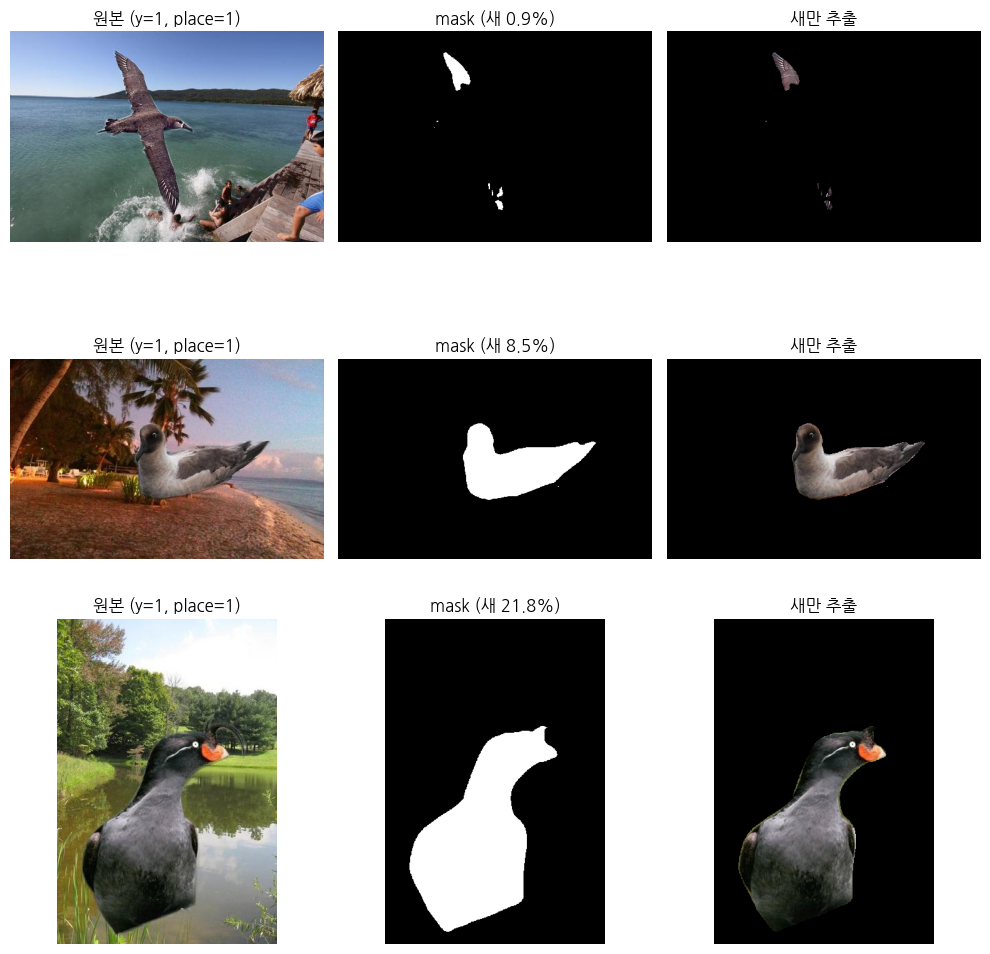

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    img, y, place = load_raw_image(i * 50)   # 0, 50, 100번째
    mask = get_bird_mask(img)
    ratio = mask.mean()  # 새 픽셀 비율

    axes[i][0].imshow(img);                 axes[i][0].set_title(f"원본 (y={y}, place={place})")
    axes[i][1].imshow(mask, cmap="gray");   axes[i][1].set_title(f"mask (새 {ratio:.1%})")
    # 새만 남기고 배경 검게
    masked = np.array(img) * mask[:, :, None]
    axes[i][2].imshow(masked.astype("uint8")); axes[i][2].set_title("새만 추출")
    for ax in axes[i]: ax.axis("off")
plt.tight_layout(); plt.show()

샘플 300장의 새 픽셀 비율:
  평균 12.7%, 중앙값 11.0%
  최소 0.0%, 최대 60.8%

  비율 >= 1% 인 이미지: 98.0%  (이만큼 합성에 쓸 수 있음)
  비율 >= 3% 인 이미지: 96.0%  (이만큼 합성에 쓸 수 있음)
  비율 >= 5% 인 이미지: 88.0%  (이만큼 합성에 쓸 수 있음)
  비율 >= 10% 인 이미지: 55.3%  (이만큼 합성에 쓸 수 있음)


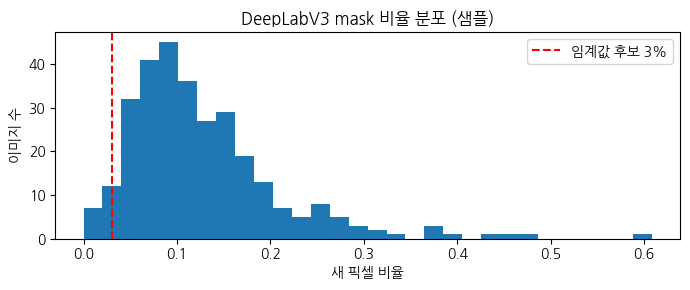

In [18]:
import random as _rnd

N_SAMPLE = 300
idxs = _rnd.sample(range(len(train_set)), N_SAMPLE)

ratios = []
for i in idxs:
    img, y, place = load_raw_image(i)
    m = get_bird_mask(img)
    ratios.append(m.mean())

ratios = np.array(ratios)

# 분포 출력
print(f"샘플 {N_SAMPLE}장의 새 픽셀 비율:")
print(f"  평균 {ratios.mean():.1%}, 중앙값 {np.median(ratios):.1%}")
print(f"  최소 {ratios.min():.1%}, 최대 {ratios.max():.1%}")
print()
for thr in [0.01, 0.03, 0.05, 0.10]:
    frac = (ratios >= thr).mean()
    print(f"  비율 >= {thr:.0%} 인 이미지: {frac:.1%}  (이만큼 합성에 쓸 수 있음)")

# 히스토그램
import matplotlib.pyplot as plt
plt.figure(figsize=(7,3))
plt.hist(ratios, bins=30)
plt.xlabel("새 픽셀 비율"); plt.ylabel("이미지 수")
plt.title("DeepLabV3 mask 비율 분포 (샘플)")
plt.axvline(0.03, color="r", linestyle="--", label="임계값 후보 3%")
plt.legend(); plt.tight_layout(); plt.show()

In [19]:
import pickle
from tqdm.auto import tqdm

MASK_THR = 0.03   # 새 비율 3% 미만은 "못 잡음"으로 처리
BG_POOL_PATH = os.path.join(CKPT_DIR, "bg_pool.pkl")
BG_SIZE = (224, 224)   # 배경 풀에 저장할 통일 크기

def collect_bg_pool():
    pool = {0: [], 1: []}   # 0=땅 배경, 1=물 배경
    mask_ratios = []        # 각 train 이미지의 새 비율 (나중에 합성에서 재사용)
    for i in tqdm(range(len(train_set)), desc="배경 풀 수집"):
        img, y, place = load_raw_image(i)
        m = get_bird_mask(img)
        mask_ratios.append(m.mean())
        if m.mean() < MASK_THR:
            continue   # 새 못 잡은 건 배경 풀에 안 씀
        # 배경 영역만 남기고 새는 검게 → 통일 크기로 저장
        arr = np.array(img.resize(BG_SIZE))
        m_small = np.array(Image.fromarray(m.astype("uint8")*255).resize(BG_SIZE)) > 127
        bg = arr.copy()
        bg[m_small] = bg[~m_small].mean(axis=0)   # 새 자리를 배경 평균색으로 메움
        pool[place].append(bg.astype("uint8"))
    return pool, np.array(mask_ratios)

if os.path.exists(BG_POOL_PATH):
    print("저장된 배경 풀 불러오는 중...")
    with open(BG_POOL_PATH, "rb") as f:
        data = pickle.load(f)
    bg_pool, mask_ratios = data["pool"], data["ratios"]
else:
    bg_pool, mask_ratios = collect_bg_pool()
    with open(BG_POOL_PATH, "wb") as f:
        pickle.dump({"pool": bg_pool, "ratios": mask_ratios}, f)
    print("배경 풀 저장 완료")

print(f"땅 배경: {len(bg_pool[0])}장, 물 배경: {len(bg_pool[1])}장")
print(f"mask 잘 잡힌 비율: {(mask_ratios >= MASK_THR).mean():.1%}")

저장된 배경 풀 불러오는 중...
땅 배경: 3414장, 물 배경: 1173장
mask 잘 잡힌 비율: 95.7%


In [20]:

import random as _rnd

BGRAND_DIR = "/content/wb_bgrand"   # 배경랜덤 이미지 저장 (로컬)
os.makedirs(BGRAND_DIR, exist_ok=True)

def make_bg_random_dataset():
    records = []   # (저장경로, y, place_원본)
    for i in tqdm(range(len(train_set)), desc="배경 랜덤 합성"):
        img, y, place = load_raw_image(i)
        out_path = os.path.join(BGRAND_DIR, f"{i:05d}.png")

        if mask_ratios[i] < MASK_THR:
            # 새 못 잡음 → 원본 그대로 (224 리사이즈)
            img.resize(BG_SIZE).save(out_path)
            records.append((out_path, y, place))
            continue

        # 새 mask 추출
        m = get_bird_mask(img)
        arr = np.array(img.resize(BG_SIZE))
        m_small = np.array(Image.fromarray(m.astype("uint8")*255).resize(BG_SIZE)) > 127

        # 랜덤 배경 고르기: 물/땅 50/50 (새 종류와 무관 → 상관관계 끊기)
        bg_place = _rnd.randint(0, 1)
        if len(bg_pool[bg_place]) == 0:
            bg_place = 1 - bg_place   # 한쪽이 비면 반대쪽
        bg = bg_pool[bg_place][_rnd.randint(0, len(bg_pool[bg_place]) - 1)].copy()

        # 합성: 새 자리는 새, 나머지는 배경
        out = np.where(m_small[:, :, None], arr, bg).astype("uint8")
        Image.fromarray(out).save(out_path)
        records.append((out_path, y, bg_place))   # place는 새로 붙인 배경 기준
    return records

BGRAND_REC_PATH = os.path.join(CKPT_DIR, "bgrand_records.pkl")
if os.path.exists(BGRAND_REC_PATH) and len(os.listdir(BGRAND_DIR)) > 4000:
    with open(BGRAND_REC_PATH, "rb") as f:
        bgrand_records = pickle.load(f)
    print("저장된 배경랜덤 데이터 사용")
else:
    bgrand_records = make_bg_random_dataset()
    with open(BGRAND_REC_PATH, "wb") as f:
        pickle.dump(bgrand_records, f)
    print("배경 랜덤 데이터 생성 완료")

print(f"총 {len(bgrand_records)}장 생성, 위치: {BGRAND_DIR}")

배경 랜덤 합성:   0%|          | 0/4795 [00:00<?, ?it/s]

배경 랜덤 데이터 생성 완료
총 4795장 생성, 위치: /content/wb_bgrand


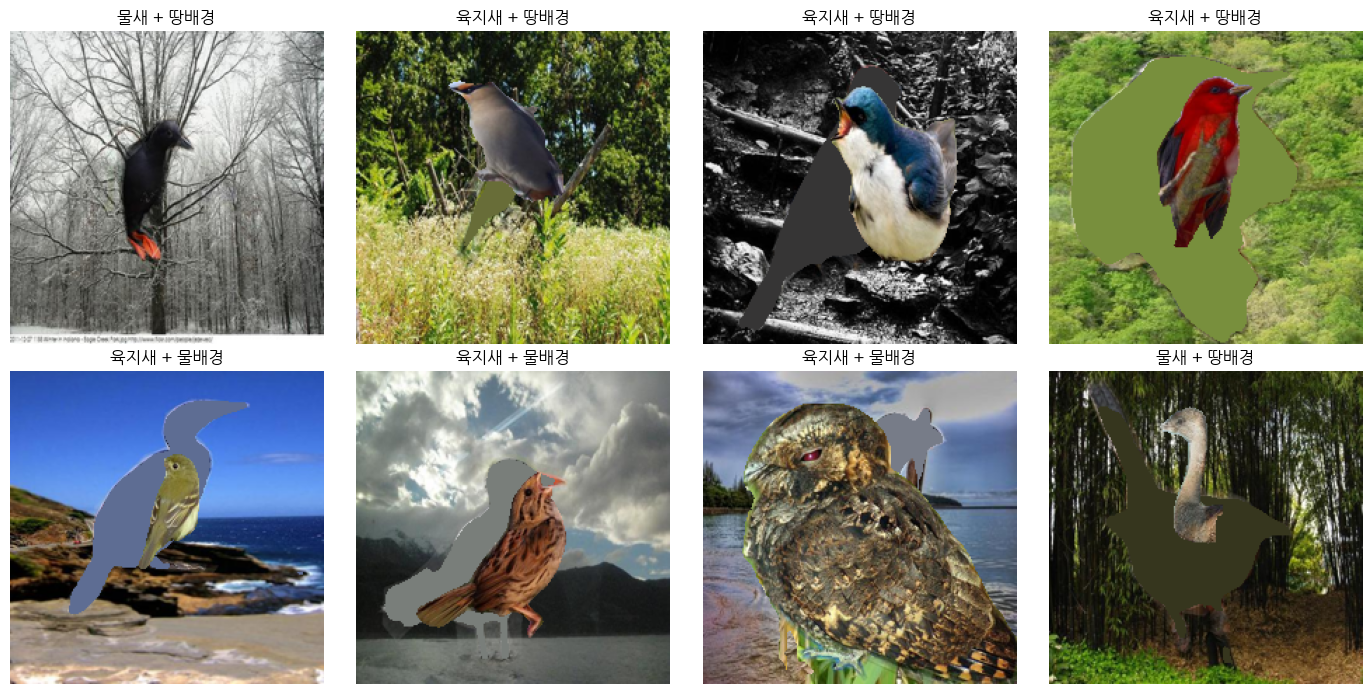

In [21]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, rec in zip(axes.flat, _rnd.sample(bgrand_records, 8)):
    path, y, place = rec
    ax.imshow(Image.open(path))
    bird = "물새" if y == 1 else "육지새"
    bg = "물배경" if place == 1 else "땅배경"
    ax.set_title(f"{bird} + {bg}"); ax.axis("off")
plt.tight_layout(); plt.show()

### 합성 데이터로 학습

`train_experiment_bgrand`는 학습 로더만 배경랜덤 데이터로 바꿔 끼우고,
검증·테스트는 **원본 데이터 그대로** 쓴다. 평가 기준을 바꾸지 않아야 E1~E4와 직접 비교할 수 있다.

In [22]:
from torch.utils.data import Dataset

class BGRandDataset(Dataset):
    """배경랜덤 합성 이미지 train 데이터셋. (x, y, metadata) 반환 — 기존 코드 호환."""
    def __init__(self, records, transform):
        self.records = records      # (path, y, place) 리스트
        self.transform = transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, i):
        path, y, place = self.records[i]
        img = Image.open(path).convert("RGB")
        x = self.transform(img)
        # metadata: [place, y] 형식 (make_group이 md[:,0]=place 쓰니까)
        md = torch.tensor([place, y])
        return x, torch.tensor(y), md

# 배경랜덤 train 로더 (transform은 기존과 동일)
bgrand_train_set = BGRandDataset(bgrand_records, tform)
bgrand_train_loader = DataLoader(bgrand_train_set, batch_size=BATCH,
                                 shuffle=True, num_workers=2, pin_memory=True)
print(f"배경랜덤 train: {len(bgrand_train_set)}장")

배경랜덤 train: 4795장


In [23]:
def train_experiment_bgrand(name, method, weight_decay, lr, epochs=100, eta=0.01, seed=0):
    global train_loader
    original = train_loader          # 원래 로더 백업
    train_loader = bgrand_train_loader   # 배경랜덤으로 교체
    try:
        result = train_experiment(name, method, weight_decay, lr, epochs, eta, seed)
    finally:
        train_loader = original      # 끝나면 원래대로 복구
    return result

In [24]:
import gc

BGRAND_EXP = {
    "E5_ERM_weak_bgrand":   dict(method="erm", weight_decay=1e-4, lr=1e-3),
    "E6_DRO_strong_bgrand": dict(method="dro", weight_decay=1.0,  lr=1e-5, eta=0.01),
}

bgrand_results = {}
for name, cfg in BGRAND_EXP.items():
    rpath = os.path.join(CKPT_DIR, f"{name}_result.json")
    if os.path.exists(rpath):
        print(f"[{name}] 이미 완료 — 건너뜀")
        bgrand_results[name] = json.load(open(rpath))
        continue
    print(f"\n========== {name} ==========")
    bgrand_results[name] = train_experiment_bgrand(name, epochs=100, **cfg)
    gc.collect(); torch.cuda.empty_cache()

[E5_ERM_weak_bgrand] 이미 완료 — 건너뜀
[E6_DRO_strong_bgrand] 이미 완료 — 건너뜀


In [25]:
import os, json
ALL6 = ["E1_ERM_weak", "E2_DRO_weak", "E3_DRO_strong", "E4_ERM_strong",
        "E5_ERM_weak_bgrand", "E6_DRO_strong_bgrand"]

print(f"{'실험':<24}{'avg':>8}{'worst':>8}")
print("-" * 40)
L = {}
for name in ALL6:
    p = os.path.join(CKPT_DIR, f"{name}_result.json")
    if os.path.exists(p):
        t = json.load(open(p))["test"]; L[name] = t
        print(f"{name:<24}{t['avg']:>8.3f}{t['worst']:>8.3f}")
    else:
        print(f"{name:<24}{'(아직 없음)':>16}")

print("\n=== 핵심 비교 (worst-group) ===")
def w(n): return L[n]["worst"] if n in L else None
if w("E1_ERM_weak") and w("E5_ERM_weak_bgrand"):
    print(f"데이터만 고치기:  E1(원본) {w('E1_ERM_weak'):.3f} → E5(배경랜덤) {w('E5_ERM_weak_bgrand'):.3f}")
if w("E3_DRO_strong") and w("E6_DRO_strong_bgrand"):
    print(f"최고+배경랜덤:    E3(원본) {w('E3_DRO_strong'):.3f} → E6(배경랜덤) {w('E6_DRO_strong_bgrand'):.3f}")

실험                           avg   worst
----------------------------------------
E1_ERM_weak                0.857   0.678
E2_DRO_weak                0.923   0.854
E3_DRO_strong              0.906   0.862
E4_ERM_strong              0.765   0.184
E5_ERM_weak_bgrand         0.950   0.891
E6_DRO_strong_bgrand       0.915   0.897

=== 핵심 비교 (worst-group) ===
데이터만 고치기:  E1(원본) 0.678 → E5(배경랜덤) 0.891
최고+배경랜덤:    E3(원본) 0.862 → E6(배경랜덤) 0.897


### 최종 결과

| 실험 | 손실 | L2 | 학습 데이터 | avg | **worst** |
|---|---|---|---|---|---|
| E1 | ERM | 약함 | 원본 | 0.857 | 0.678 |
| E2 | GroupDRO | 약함 | 원본 | 0.923 | 0.854 |
| E3 | GroupDRO | 강함 | 원본 | 0.906 | 0.862 |
| E4 | ERM | 강함 | 원본 | 0.765 | **0.184** |
| E5 | ERM | 약함 | 배경랜덤 | 0.950 | 0.891 |
| E6 | GroupDRO | 강함 | 배경랜덤 | 0.915 | **0.897** |

**관찰 1 — 데이터를 고치는 쪽이 알고리즘을 고치는 쪽보다 효과가 컸다.**
E5는 손실 함수를 그대로 ERM으로 두고 데이터만 바꿨는데 worst 0.891로,
그룹 라벨을 쓰는 E3(0.862)보다 높았다. E1 대비 **+21.3%p**다.
그룹 라벨 없이도 개입 지점을 데이터로 옮기면 비슷하거나 더 나은 결과를 얻을 수 있다는 뜻이다.

**관찰 2 — 평균 정확도도 함께 올랐다.**
GroupDRO는 보통 worst를 올리는 대신 avg를 일부 희생하는데(E3: 0.906),
E5는 avg 0.950으로 가장 높다. 지름길을 제거하면 트레이드오프 없이 양쪽이 개선될 수 있다.

**관찰 3 — 둘을 합치면 소폭 추가 개선.** E6은 worst 0.897로 최고지만 E5와의 차이는 0.6%p로,
배경 랜덤화가 이미 대부분의 이득을 가져간 뒤였다.

**한계.** 단일 시드(seed=0)로만 돌려 분산을 확인하지 못했고,
배경 합성이 만든 인공적인 경계가 별도의 단서로 작용했을 가능성을 배제하지 못했다.

## 6. 왜 좋아졌는지 확인 — Grad-CAM과 배경 디코더빌리티

정확도 숫자만으로는 "배경을 덜 본다"를 증명할 수 없다. 두 가지로 확인한다.

1. **Grad-CAM** — worst 그룹(물새+땅) 샘플에서 모델이 실제로 어디를 보는지 시각화한다.
2. **배경 디코더빌리티** — fc 직전 2048차원 feature만으로 **배경(물/땅)을 얼마나 맞힐 수 있는지** SVM으로 측정한다.
   맞히기 쉬울수록 feature에 배경 정보가 많이 남아 있다는 뜻이므로, 고친 모델일수록 이 값이 낮아야 한다.

In [26]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

def gradcam(model, x, target_class=None):
    """x: (1,3,224,224) 텐서. ResNet50 마지막 conv layer 기준 Grad-CAM 히트맵 반환."""
    model.eval()
    feats = {}
    # 마지막 conv block(layer4)의 출력을 후킹
    def fwd_hook(m, i, o): feats["act"] = o
    def bwd_hook(m, gi, go): feats["grad"] = go[0]
    h1 = model.layer4.register_forward_hook(fwd_hook)
    h2 = model.layer4.register_full_backward_hook(bwd_hook)

    out = model(x)
    if target_class is None:
        target_class = out.argmax(1).item()
    model.zero_grad()
    out[0, target_class].backward()

    grad = feats["grad"][0]          # (C,h,w)
    act  = feats["act"][0]           # (C,h,w)
    weights = grad.mean(dim=(1, 2))  # (C,)
    cam = F.relu((weights[:, None, None] * act).sum(0))  # (h,w)
    cam = cam / (cam.max() + 1e-8)
    cam = F.interpolate(cam[None, None], size=(224, 224), mode="bilinear",
                        align_corners=False)[0, 0].detach().cpu().numpy()
    h1.remove(); h2.remove()
    return cam, target_class

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 248MB/s]


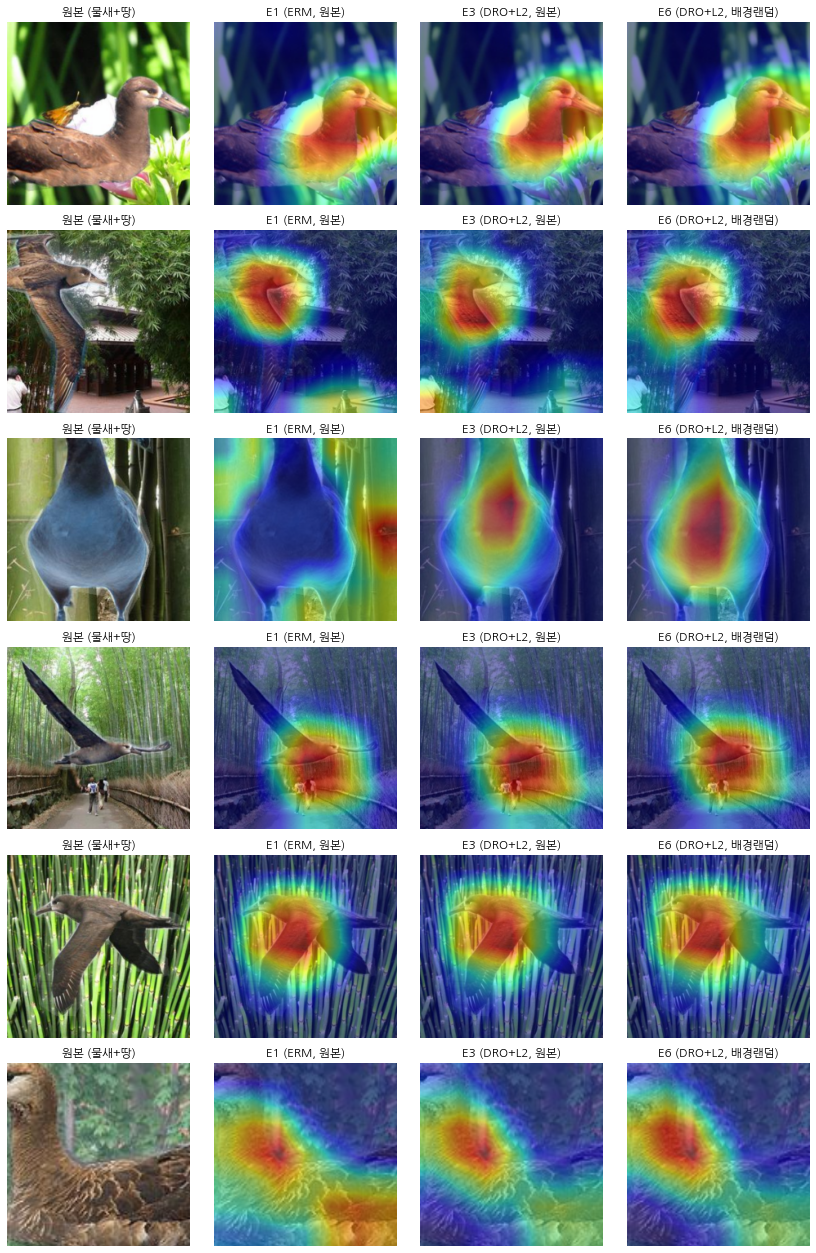

In [27]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 그림 용량 제한 (원래 설정은 파일이 37MB까지 커짐)
plt.rcParams["figure.dpi"] = 70
plt.rcParams["savefig.dpi"] = 70

COMPARE = {
    "E1 (ERM, 원본)":        "E1_ERM_weak_best.pt",
    "E3 (DRO+L2, 원본)":     "E3_DRO_strong_best.pt",
    "E6 (DRO+L2, 배경랜덤)": "E6_DRO_strong_bgrand_best.pt",
}

def load_model(ckpt_name):
    m = get_resnet50().to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(CKPT_DIR, ckpt_name), map_location=DEVICE))
    m.eval()
    return m

def find_worst_group_samples(n=6):
    samples = []
    for i in range(len(test_set)):
        x, y, mdm = test_set[i]
        g = int(y) * 2 + int(mdm[0])
        if g == 2:
            samples.append(i)
        if len(samples) >= n: break
    return samples

sample_idxs = find_worst_group_samples()
cam_models = {name: load_model(ck) for name, ck in COMPARE.items()}   # ← 이름 바꿈

fig, axes = plt.subplots(len(sample_idxs), len(COMPARE) + 1,
                         figsize=(3 * (len(COMPARE) + 1), 3 * len(sample_idxs)))
for r, idx in enumerate(sample_idxs):
    x, y, mdm = test_set[idx]
    xb = x.unsqueeze(0).to(DEVICE)
    mean = np.array([0.485, 0.456, 0.406]); std = np.array([0.229, 0.224, 0.225])
    img = (x.permute(1, 2, 0).cpu().numpy() * std + mean).clip(0, 1)

    axes[r][0].imshow(img); axes[r][0].set_title("원본 (물새+땅)"); axes[r][0].axis("off")
    for c, (name, model) in enumerate(cam_models.items(), start=1):   # ← 여기도
        cam, _ = gradcam(model, xb)
        axes[r][c].imshow(img)
        axes[r][c].imshow(cam, cmap="jet", alpha=0.5)
        axes[r][c].set_title(name); axes[r][c].axis("off")
plt.tight_layout(); plt.show()

In [28]:
import random as _rnd
from tqdm.auto import tqdm

BGF_N = 500   # 테스트셋에서 뽑을 장수

_rng = _rnd.Random(0)
bgf_idxs = _rng.sample(range(len(test_set)), BGF_N)

bgf_data = []   # (전처리된 텐서, place)
for i in tqdm(bgf_idxs, desc="새 제거"):
    img, y, place = load_raw_image(i, subset=test_set)
    m = get_bird_mask(img)
    arr = np.array(img)
    if m.any() and (~m).any():
        arr = arr.copy()
        arr[m] = arr[~m].mean(axis=0)   # 새 자리를 배경 평균색으로
    bgf_data.append((tform(Image.fromarray(arr.astype("uint8"))), place))

print(f"{len(bgf_data)}장 준비 완료 (새를 지우고 배경만 남긴 이미지)")

새 제거:   0%|          | 0/500 [00:00<?, ?it/s]

500장 준비 완료 (새를 지우고 배경만 남긴 이미지)


In [29]:
@torch.no_grad()
def background_following_rate(model, batch=64):
    """새가 없는 이미지에서, 예측이 배경 종류와 일치하는 비율."""
    model.eval()
    follow = 0
    for s in range(0, len(bgf_data), batch):
        chunk = bgf_data[s:s + batch]
        x = torch.stack([c[0] for c in chunk]).to(DEVICE)
        places = torch.tensor([c[1] for c in chunk])
        pred = model(x).argmax(1).cpu()
        follow += (pred == places).sum().item()   # 물배경→물새, 땅배경→육지새
    return follow / len(bgf_data)


BGF_COMPARE = {
    "E1 (ERM, 원본)":        "E1_ERM_weak_best.pt",
    "E3 (DRO+L2, 원본)":     "E3_DRO_strong_best.pt",
    "E5 (ERM, 배경랜덤)":    "E5_ERM_weak_bgrand_best.pt",
    "E6 (DRO+L2, 배경랜덤)": "E6_DRO_strong_bgrand_best.pt",
}

print("=== 배경추종률 (낮을수록 배경 의존 ↓) ===\n")
for name, ck in BGF_COMPARE.items():
    m = load_model(ck)
    print(f"{name:<24} {background_following_rate(m):.3f}")
    del m
    torch.cuda.empty_cache()

=== 배경추종률 (낮을수록 배경 의존 ↓) ===

E1 (ERM, 원본)             0.882
E3 (DRO+L2, 원본)          0.752
E5 (ERM, 배경랜덤)           0.602
E6 (DRO+L2, 배경랜덤)        0.548


In [30]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

@torch.no_grad()
def extract_features(model, loader, max_n=1500):
    """모델의 fc 직전 feature(2048차원) + 라벨/배경 추출."""
    model.eval()
    # fc 직전 feature를 후킹으로 빼냄
    feats = []
    def hook(m, i, o): feats.append(o.detach())
    h = model.avgpool.register_forward_hook(hook)

    all_feat, all_y, all_place = [], [], []
    n = 0
    for x, y, mdm in loader:
        feats.clear()
        x = x.to(DEVICE)
        _ = model(x)
        f = feats[0].squeeze(-1).squeeze(-1).cpu().numpy()  # (B, 2048)
        all_feat.append(f)
        all_y.append(y.numpy())
        all_place.append(mdm[:, 0].numpy())   # 배경: 0=땅, 1=물
        n += len(y)
        if n >= max_n: break
    h.remove()
    return (np.concatenate(all_feat), np.concatenate(all_y), np.concatenate(all_place))

In [31]:
def bg_decodability(model, name):
    """feature로 배경(물/땅)을 얼마나 맞히나 → 배경 의존도."""
    feat, y, place = extract_features(model, test_loader)
    # 표준화 후 SVM 학습/평가 (배경 라벨 분류)
    Xtr, Xte, ytr, yte = train_test_split(feat, place, test_size=0.3,
                                          random_state=0, stratify=place)
    scaler = StandardScaler().fit(Xtr)
    clf = SVC(kernel="rbf", C=1.0).fit(scaler.transform(Xtr), ytr)
    acc = clf.score(scaler.transform(Xte), yte)
    print(f"{name:<28} 배경 분류 정확도: {acc:.3f}")
    return acc, feat, place

print("=== feature에서 배경을 얼마나 맞히나 (높을수록 배경 의존 ↑) ===\n")
bg_results = {}
for name, model in cam_models.items():
    acc, feat, place = bg_decodability(model, name)
    bg_results[name] = {"acc": acc, "feat": feat, "place": place}

print("\n세 모델 모두 0.92 내외 — feature에는 배경 정보가 그대로 남아 있음")
print("(배경추종률은 0.882 → 0.548로 감소 → 정보는 남아 있으나 사용되지 않음)")

=== feature에서 배경을 얼마나 맞히나 (높을수록 배경 의존 ↑) ===

E1 (ERM, 원본)                 배경 분류 정확도: 0.924
E3 (DRO+L2, 원본)              배경 분류 정확도: 0.924
E6 (DRO+L2, 배경랜덤)            배경 분류 정확도: 0.918

세 모델 모두 0.92 내외 — feature에는 배경 정보가 그대로 남아 있음
(배경추종률은 0.882 → 0.548로 감소 → 정보는 남아 있으나 사용되지 않음)


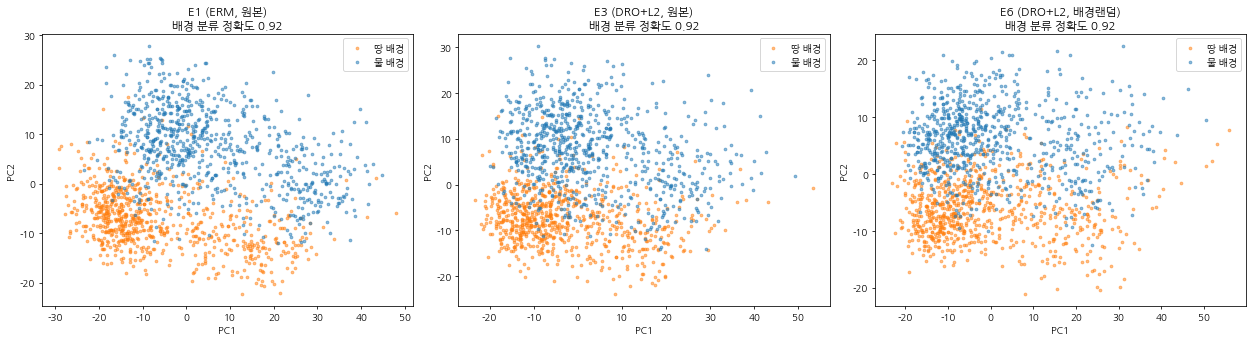

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(bg_results), figsize=(6 * len(bg_results), 5))
if len(bg_results) == 1: axes = [axes]

for ax, (name, d) in zip(axes, bg_results.items()):
    feat, place = d["feat"], d["place"]
    # 2D로 축소
    p2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(feat))
    for pl, color, label in [(0, "tab:orange", "땅 배경"), (1, "tab:blue", "물 배경")]:
        m = (place == pl)
        ax.scatter(p2[m, 0], p2[m, 1], s=8, alpha=0.5, c=color, label=label)
    ax.set_title(f"{name}\n배경 분류 정확도 {d['acc']:.2f}")
    ax.legend(); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout(); plt.show()